# Crosslinking effects on ligation probabilities

This notebook analyzes how crosslinking affects simulated ligation probabilities and compares these observables with contact probabilities from the underlying native chromatin ensemble.

## Purpose

- Load aggregated ligation outputs for different crosslinking conditions  
- Compute and plot ligation probability as a function of genomic distance  
- Compare ligation probabilities with native contact probabilities  
- Assess how crosslinking preserves structural information in simulated Hi-C readouts  

## Notes

- This notebook supports selected supplementary analyses.  
- It is representative and not intended to reproduce every figure panel individually.  
Input data are expected in `../../data/processed/crosslinking_efficiency/`,
`../../data/processed/contact_probabilities/ensemble/`, and
`../../data/processed/experimental/`.

**Note:** The `.npz` datasets required for this notebook are not included in this repository and are available on Zenodo: https://doi.org/10.5281/zenodo.19682913

In [2]:
import hoomd, hoomd.md
import mdtraj as md
import mbuild as mb
import numpy  as np
import random
import os.path
import sys
import scipy as sp
from scipy.spatial import distance
import gsd
import gsd.fl, gsd.hoomd
import warnings
warnings.filterwarnings('ignore')

import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.sparse as sparse
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
output_dir = "../../data/processed/crosslinking_efficiency"
g_xl_0 = np.load(output_dir+'/0000_xlbeads/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_4500_rc_1.5.npz', allow_pickle=True)
g_xl_100 = np.load(output_dir+'/0100_xlbeads/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_4500_rc_1.5.npz', allow_pickle=True)
g_xl_500 = np.load(output_dir+'/0500_xlbeads/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_4500_rc_1.5.npz', allow_pickle=True)
g_xl_1000 = np.load(output_dir+'/1000_xlbeads/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_4500_rc_1.5.npz', allow_pickle=True)
g_xl_3000 = np.load(output_dir+'/3000_xlbeads/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_4500_rc_1.5.npz', allow_pickle=True)
g_xl_5000 = np.load(output_dir+'/5000_xlbeads/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_4500_rc_1.5.npz', allow_pickle=True)
g_xl_5500 = np.load(output_dir+'/5500_xlbeads/combined_ft_lig_data_C_7_region_95.4-96.5_nkeep_4500_rc_1.5.npz', allow_pickle=True)

In [ ]:
print(g_xl_0.files, g_xl_100.files, g_xl_500.files, g_xl_1000.files, g_xl_3000.files, g_xl_5000.files, g_xl_5500.files) 

['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_final', 'init_contact_map_final_2', 'rthresh', 'initial_distance_final', 'Pcycle_L_final', 'Ncycle_L_final', 'Nlong_L_final', 'cycle_bins', 'ligation_map_global_new', 'ligation_prob_global_new', 'p_ligation_new', 'tot_nlig_new', 'cum_history_mat'] ['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_final', 'init_contact_map_final_2', 'rthresh', 'initial_distance_final', 'Pcycle_L_final', 'Ncycle_L_final', 'Nlong_L_final', 'cycle_bins', 'ligation_map_global_new', 'ligation_prob_global_new', 'p_ligation_new', 'tot_nlig_new', 'cum_history_mat'] ['ligation_prob_global', 'ligation_map_global', 'ligation_events', 'self_ligation_events', 'nf', 'p_ligation1', 'p_ligation2', 'ligation_distances', 'init_contact_map_fin

In [6]:
lpg_xl_0=g_xl_0['ligation_prob_global']
lmg_xl_0=g_xl_0['ligation_map_global']
lev_xl_0=g_xl_0['ligation_events']
sle_xl_0=g_xl_0['self_ligation_events']
nf_xl_0=g_xl_0['nf']
pl1_xl_0=g_xl_0['p_ligation1']
pl2_xl_0=g_xl_0['p_ligation2']
ld_xl_0=g_xl_0['ligation_distances']

Nlong_L_xl_0=g_xl_0['Nlong_L_final']
Pcycle_L_xl_0=g_xl_0['Pcycle_L_final']
Ncycle_L_xl_0=g_xl_0['Ncycle_L_final']
cycle_bins_xl_0=g_xl_0['cycle_bins']
icm_xl_0=g_xl_0['init_contact_map_final']
icm2_xl_0=g_xl_0['init_contact_map_final_2']
rthresh_xl_0=g_xl_0['rthresh']
idm_xl_0=g_xl_0['initial_distance_final']
nf_xl_0=g_xl_0['nf']

lmgn_xl_0=g_xl_0['ligation_map_global_new']
lpgn_xl_0=g_xl_0['ligation_prob_global_new']
pln_xl_0=g_xl_0['p_ligation_new']
tnln_xl_0=g_xl_0['tot_nlig_new']
hist_xl_0=g_xl_0['cum_history_mat']

lpg_xl_100=g_xl_100['ligation_prob_global']
lmg_xl_100=g_xl_100['ligation_map_global']
lev_xl_100=g_xl_100['ligation_events']
sle_xl_100=g_xl_100['self_ligation_events']
nf_xl_100=g_xl_100['nf']
pl1_xl_100=g_xl_100['p_ligation1']
pl2_xl_100=g_xl_100['p_ligation2']
ld_xl_100=g_xl_100['ligation_distances']

Nlong_L_xl_100=g_xl_100['Nlong_L_final']
Pcycle_L_xl_100=g_xl_100['Pcycle_L_final']
Ncycle_L_xl_100=g_xl_100['Ncycle_L_final']
cycle_bins_xl_100=g_xl_100['cycle_bins']
icm_xl_100=g_xl_100['init_contact_map_final']
icm2_xl_100=g_xl_100['init_contact_map_final_2']
rthresh_xl_100=g_xl_100['rthresh']
idm_xl_100=g_xl_100['initial_distance_final']
nf_xl_100=g_xl_100['nf']

lmgn_xl_100=g_xl_100['ligation_map_global_new']
lpgn_xl_100=g_xl_100['ligation_prob_global_new']
pln_xl_100=g_xl_100['p_ligation_new']
tnln_xl_100=g_xl_100['tot_nlig_new']
hist_xl_100=g_xl_100['cum_history_mat']

lpg_xl_500=g_xl_500['ligation_prob_global']
lmg_xl_500=g_xl_500['ligation_map_global']
lev_xl_500=g_xl_500['ligation_events']
sle_xl_500=g_xl_500['self_ligation_events']
nf_xl_500=g_xl_500['nf']
pl1_xl_500=g_xl_500['p_ligation1']
pl2_xl_500=g_xl_500['p_ligation2']
ld_xl_500=g_xl_500['ligation_distances']

Nlong_L_xl_500=g_xl_500['Nlong_L_final']
Pcycle_L_xl_500=g_xl_500['Pcycle_L_final']
Ncycle_L_xl_500=g_xl_500['Ncycle_L_final']
cycle_bins_xl_500=g_xl_500['cycle_bins']
icm_xl_500=g_xl_500['init_contact_map_final']
icm2_xl_500=g_xl_500['init_contact_map_final_2']
rthresh_xl_500=g_xl_500['rthresh']
idm_xl_500=g_xl_500['initial_distance_final']
nf_xl_500=g_xl_500['nf']

lmgn_xl_500=g_xl_500['ligation_map_global_new']
lpgn_xl_500=g_xl_500['ligation_prob_global_new']
pln_xl_500=g_xl_500['p_ligation_new']
tnln_xl_500=g_xl_500['tot_nlig_new']
hist_xl_500=g_xl_500['cum_history_mat']

lpg_xl_1000=g_xl_1000['ligation_prob_global']
lmg_xl_1000=g_xl_1000['ligation_map_global']
lev_xl_1000=g_xl_1000['ligation_events']
sle_xl_1000=g_xl_1000['self_ligation_events']
nf_xl_1000=g_xl_1000['nf']
pl1_xl_1000=g_xl_1000['p_ligation1']
pl2_xl_1000=g_xl_1000['p_ligation2']
ld_xl_1000=g_xl_1000['ligation_distances']

Nlong_L_xl_1000=g_xl_1000['Nlong_L_final']
Pcycle_L_xl_1000=g_xl_1000['Pcycle_L_final']
Ncycle_L_xl_1000=g_xl_1000['Ncycle_L_final']
cycle_bins_xl_1000=g_xl_1000['cycle_bins']
icm_xl_1000=g_xl_1000['init_contact_map_final']
icm2_xl_1000=g_xl_1000['init_contact_map_final_2']
rthresh_xl_1000=g_xl_1000['rthresh']
idm_xl_1000=g_xl_1000['initial_distance_final']
nf_xl_1000=g_xl_1000['nf']

lmgn_xl_1000=g_xl_1000['ligation_map_global_new']
lpgn_xl_1000=g_xl_1000['ligation_prob_global_new']
pln_xl_1000=g_xl_1000['p_ligation_new']
tnln_xl_1000=g_xl_1000['tot_nlig_new']
hist_xl_1000=g_xl_1000['cum_history_mat']

lpg_xl_1000=g_xl_1000['ligation_prob_global']
lmg_xl_1000=g_xl_1000['ligation_map_global']
lev_xl_1000=g_xl_1000['ligation_events']
sle_xl_1000=g_xl_1000['self_ligation_events']
nf_xl_1000=g_xl_1000['nf']
pl1_xl_1000=g_xl_1000['p_ligation1']
pl2_xl_1000=g_xl_1000['p_ligation2']
ld_xl_1000=g_xl_1000['ligation_distances']

lpg_xl_3000=g_xl_3000['ligation_prob_global']
lmg_xl_3000=g_xl_3000['ligation_map_global']
lev_xl_3000=g_xl_3000['ligation_events']
sle_xl_3000=g_xl_3000['self_ligation_events']
nf_xl_3000=g_xl_3000['nf']
pl1_xl_3000=g_xl_3000['p_ligation1']
pl2_xl_3000=g_xl_3000['p_ligation2']
ld_xl_3000=g_xl_3000['ligation_distances']

Nlong_L_xl_3000=g_xl_3000['Nlong_L_final']
Pcycle_L_xl_3000=g_xl_3000['Pcycle_L_final']
Ncycle_L_xl_3000=g_xl_3000['Ncycle_L_final']
cycle_bins_xl_3000=g_xl_3000['cycle_bins']
icm_xl_3000=g_xl_3000['init_contact_map_final']
icm2_xl_3000=g_xl_3000['init_contact_map_final_2']
rthresh_xl_3000=g_xl_3000['rthresh']
idm_xl_3000=g_xl_3000['initial_distance_final']
nf_xl_3000=g_xl_3000['nf']

lmgn_xl_3000=g_xl_3000['ligation_map_global_new']
lpgn_xl_3000=g_xl_3000['ligation_prob_global_new']
pln_xl_3000=g_xl_3000['p_ligation_new']
tnln_xl_3000=g_xl_3000['tot_nlig_new']
hist_xl_3000=g_xl_3000['cum_history_mat']

lpg_xl_5000=g_xl_5000['ligation_prob_global']
lmg_xl_5000=g_xl_5000['ligation_map_global']
lev_xl_5000=g_xl_5000['ligation_events']
sle_xl_5000=g_xl_5000['self_ligation_events']
nf_xl_5000=g_xl_5000['nf']
pl1_xl_5000=g_xl_5000['p_ligation1']
pl2_xl_5000=g_xl_5000['p_ligation2']
ld_xl_5000=g_xl_5000['ligation_distances']

Nlong_L_xl_5000=g_xl_5000['Nlong_L_final']
Pcycle_L_xl_5000=g_xl_5000['Pcycle_L_final']
Ncycle_L_xl_5000=g_xl_5000['Ncycle_L_final']
cycle_bins_xl_5000=g_xl_5000['cycle_bins']
icm_xl_5000=g_xl_5000['init_contact_map_final']
icm2_xl_5000=g_xl_5000['init_contact_map_final_2']
rthresh_xl_5000=g_xl_5000['rthresh']
idm_xl_5000=g_xl_5000['initial_distance_final']
nf_xl_5000=g_xl_5000['nf']

lmgn_xl_5000=g_xl_5000['ligation_map_global_new']
lpgn_xl_5000=g_xl_5000['ligation_prob_global_new']
pln_xl_5000=g_xl_5000['p_ligation_new']
tnln_xl_5000=g_xl_5000['tot_nlig_new']
hist_xl_5000=g_xl_5000['cum_history_mat']

lpg_xl_5500=g_xl_5500['ligation_prob_global']
lmg_xl_5500=g_xl_5500['ligation_map_global']
lev_xl_5500=g_xl_5500['ligation_events']
sle_xl_5500=g_xl_5500['self_ligation_events']
nf_xl_5500=g_xl_5500['nf']
pl1_xl_5500=g_xl_5500['p_ligation1']
pl2_xl_5500=g_xl_5500['p_ligation2']
ld_xl_5500=g_xl_5500['ligation_distances']

Nlong_L_xl_5500=g_xl_5500['Nlong_L_final']
Pcycle_L_xl_5500=g_xl_5500['Pcycle_L_final']
Ncycle_L_xl_5500=g_xl_5500['Ncycle_L_final']
cycle_bins_xl_5500=g_xl_5500['cycle_bins']
icm_xl_5500=g_xl_5500['init_contact_map_final']
icm2_xl_5500=g_xl_5500['init_contact_map_final_2']
rthresh_xl_5500=g_xl_5500['rthresh']
idm_xl_5500=g_xl_5500['initial_distance_final']
nf_xl_5500=g_xl_5500['nf']

lmgn_xl_5500=g_xl_5500['ligation_map_global_new']
lpgn_xl_5500=g_xl_5500['ligation_prob_global_new']
pln_xl_5500=g_xl_5500['p_ligation_new']
tnln_xl_5500=g_xl_5500['tot_nlig_new']
hist_xl_5500=g_xl_5500['cum_history_mat']

In [ ]:
print(lpg_xl_3000.shape,lmg_xl_3000.shape,lev_xl_3000.shape,nf_xl_3000.shape,pl1_xl_3000.shape,pl2_xl_3000.shape,ld_xl_3000.shape)

(4, 5499) (4, 5500, 5500) (2,) () (4, 49) (4, 49) (50,)


In [8]:
lig_probs = np.array([1.0,0.1,0.01,0.001])
No_cuts = np.array([500, 1000, 3000, 5000])
p_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$']
cuts_legend = ['No. cuts = '+str(500),'No. cuts = '+str(1000),'No. cuts = '+str(3000) ,'No. cuts = '+str(5000)]
Ncuts = len(No_cuts)
Nprobs = len(lig_probs)

No_xlbeads = np.array([0, 100, 500, 1000, 3000, 5000, 5500])
xlbeads_legend = ['No. Cross-links = '+str(0),'No. Cross-links = '+str(100),'No. Cross-links = '+str(500) ,'No. Cross-links = '+str(1000),'No. Cross-links = '+str(3000),'No. Cross-links = '+str(5000), 'No. Cross-links = '+str(5500)]

In [9]:
print(len(lpg_xl_500[2]))
gen_dist = np.linspace(0,5499,5499, dtype=int)
print(gen_dist)

5499
[   0    1    2 ... 5496 5497 5499]


In [10]:
xticks = np.linspace(1, 5500, 5499)
scale_factor = 200
scaled_xticks = scale_factor*xticks

In [ ]:
#Import experimental data from npz file at a resultion of 1KB
g_exp=np.load("../../data/processed/experimental/experimental-hic.npz", allow_pickle=True)
exp_ligprob = g_exp['exp_ligprob']
exp_map     = g_exp['ex_map']

In [12]:
#Calculation ligation probability vs genomic distance for experimental data
dmax = exp_map.shape[0] - 1
init = 1
contact_map_average = exp_map
contact_prob_average = np.zeros(dmax)
for i in range(dmax):
    contact_prob_average[i] =  np.mean(np.diagonal(contact_map_average, offset=(i+init)))    
normalize = contact_prob_average/np.sum(contact_prob_average)

In [ ]:
#Contact probability, average distance map and average contact map
cprob_dir = '../../data/processed/contact_probabilities/ensemble'
g_cprob = np.load(cprob_dir+'/distance_contact_map_C_7_region_95.4-96.5.npz', allow_pickle=True)
#print(g_cprob.files)
dma_ens=g_cprob['distance_map_average']
cma_ens=g_cprob['contact_map_average']
cpa_ens=g_cprob['contact_prob_average']
nf_ens=g_cprob['nf']

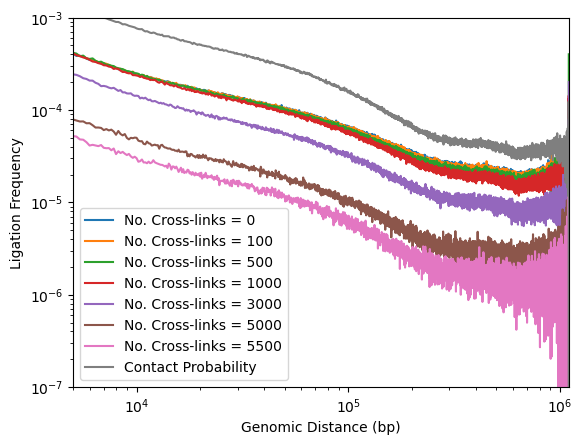

In [ ]:
#Ligation frequencies as a function of genomic distance for different crosslinking efficiencies at fast ligation rate

plt.plot(scaled_xticks, lpg_xl_0[0])
plt.plot(scaled_xticks, lpg_xl_100[0])
plt.plot(scaled_xticks, lpg_xl_500[0])
plt.plot(scaled_xticks, lpg_xl_1000[0])
plt.plot(scaled_xticks, lpg_xl_3000[0])
plt.plot(scaled_xticks, lpg_xl_5000[0])
plt.plot(scaled_xticks, lpg_xl_5500[0])

#cuts_exp_legend = ['No. Cross-links = '+str(0),'No. Cross-links = '+str(100),'No. Cross-links = '+str(500) , 'No. Cross-links = '+str(1000), 'No. Cross-links = '+str(3000), 'No. Cross-links = '+str(5000), 'No. Cross-links = '+str(5500), 'Experimental - 1Kbp', 'Contact Probability']
cuts_exp_legend = ['No. Cross-links = '+str(0),'No. Cross-links = '+str(100),'No. Cross-links = '+str(500) , 'No. Cross-links = '+str(1000), 'No. Cross-links = '+str(3000), 'No. Cross-links = '+str(5000), 'No. Cross-links = '+str(5500), 'Contact Probability']
                   
    
xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
#plt.plot(scaled_xticks_exp, normalize/200)

plt.plot(scaled_xticks, cpa_ens)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend, loc='lower left')
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Frequency')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-7,1e-3])
plt.xlim([5000,5500*200])
plt.show()

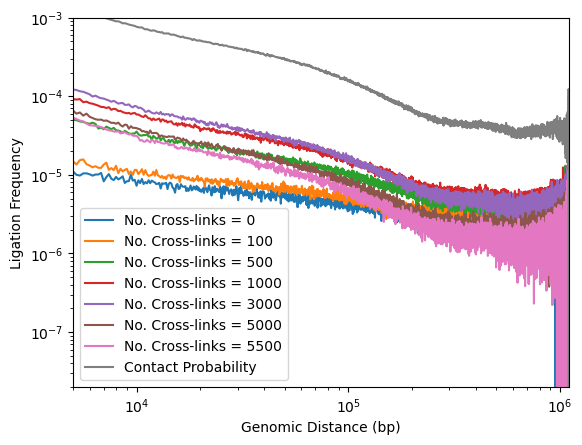

In [ ]:
#Ligation frequencies as a function of genomic distance for different crosslinking efficiencies at slow ligation rate

plt.plot(scaled_xticks, lpg_xl_0[3])
plt.plot(scaled_xticks, lpg_xl_100[3])
plt.plot(scaled_xticks, lpg_xl_500[3])
plt.plot(scaled_xticks, lpg_xl_1000[3])
plt.plot(scaled_xticks, lpg_xl_3000[3])
plt.plot(scaled_xticks, lpg_xl_5000[3])
plt.plot(scaled_xticks, lpg_xl_5500[3])

#cuts_exp_legend = ['No. Cross-links = '+str(0),'No. Cross-links = '+str(100),'No. Cross-links = '+str(500) , 'No. Cross-links = '+str(1000), 'No. Cross-links = '+str(3000), 'No. Cross-links = '+str(5000), 'No. Cross-links = '+str(5500), 'Experimental - 1Kbp']
cuts_exp_legend = ['No. Cross-links = '+str(0),'No. Cross-links = '+str(100),'No. Cross-links = '+str(500) , 'No. Cross-links = '+str(1000), 'No. Cross-links = '+str(3000), 'No. Cross-links = '+str(5000), 'No. Cross-links = '+str(5500), 'Contact Probability']
                   
    
xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
#plt.plot(scaled_xticks_exp, normalize/200)

plt.plot(scaled_xticks, cpa_ens)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(cuts_exp_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Frequency')
plt.yscale("log")
plt.xscale("log")
plt.ylim([2e-8,1e-3])
plt.xlim([5000,5500*200])
plt.show()

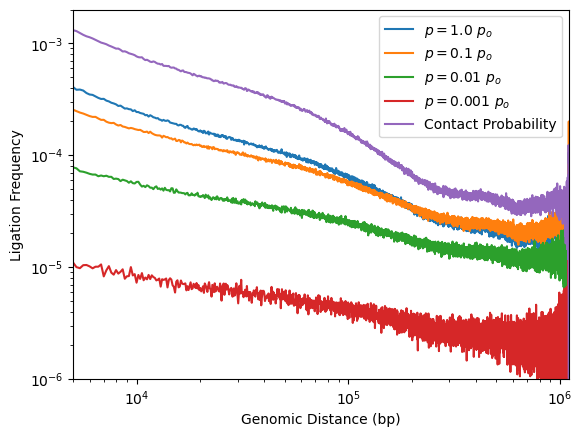

In [ ]:
#Ligation frequencies as a function of genomic distance for different ligation rates without crosslinking

plt.plot(scaled_xticks, lpg_xl_0[0])
plt.plot(scaled_xticks, lpg_xl_0[1])
plt.plot(scaled_xticks, lpg_xl_0[2])
plt.plot(scaled_xticks, lpg_xl_0[3])

#po_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$', 'Experimental - 1Kb']
po_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$', 'Contact Probability']


xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
#plt.plot(scaled_xticks_exp, normalize/100)

plt.plot(scaled_xticks, cpa_ens)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(po_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Frequency')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,2e-3])
plt.xlim([5000,5500*200])
plt.show()

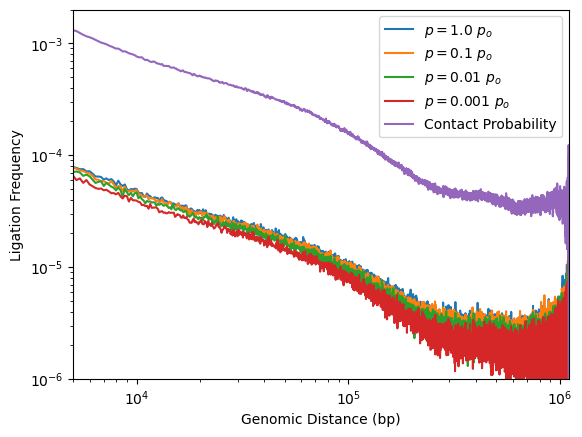

In [ ]:
#Ligation frequencies as a function of genomic distance for different ligation rates with maximal crosslinking

plt.plot(scaled_xticks, lpg_xl_5000[0])
plt.plot(scaled_xticks, lpg_xl_5000[1])
plt.plot(scaled_xticks, lpg_xl_5000[2])
plt.plot(scaled_xticks, lpg_xl_5000[3])

#po_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$', 'Experimental - 1Kb']
po_legend = [r'$p = $'+str(1.0)+r' $p_o$',r'$p = $'+str(0.1)+r' $p_o$',r'$p = $'+str(0.01)+r' $p_o$',r'$p = $'+str(0.001)+r' $p_o$', 'Contact Probability']


xticks_exp = np.linspace(1, dmax, dmax)
scale_factor_exp = 1000
scaled_xticks_exp = scale_factor_exp*xticks_exp
#plt.plot(scaled_xticks_exp, normalize/100)

plt.plot(scaled_xticks, cpa_ens)

#plt.plot([1e1,1e2],[1e-4,1e-5])
plt.legend(po_legend)
#plt.xlim([0,5500])
plt.xlabel('Genomic Distance (bp)')
plt.ylabel('Ligation Frequency')
plt.yscale("log")
plt.xscale("log")
plt.ylim([1e-6,2e-3])
plt.xlim([5000,5500*200])
plt.show()

In [ ]:
#Estimation of ligation probability scalings by fitting to power laws.

from scipy.optimize import curve_fit

def power_fit(x, a, alpha):
    return a*x**alpha

#print(len(scaled_xticks), len(cont_prob_5500))

lower_bound = 100 #49
upper_bound = 2999 #499

params_0000 = []
params_0100 = []
params_0500 = []
params_1000 = []
params_3000 = []
params_5000 = []
params_5500 = []

slope_p1e0 = []
slope_p1e1 = []
slope_p1e2 = []
slope_p1e3 = []

params_exp,  covariance_exp  = curve_fit(f = power_fit, xdata = scaled_xticks_exp[2:99], ydata = normalize[2:99], maxfev=10000)

params_cprob,  covariance_cprob  = curve_fit(f = power_fit, xdata = scaled_xticks[2:99], ydata = cpa_ens[2:99], maxfev=10000)

for i in range(Nprobs):

    param_0000, covariance_0000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_xl_0[i][lower_bound:upper_bound], maxfev=10000)
    param_0100, covariance_0100 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_xl_100[i][lower_bound:upper_bound], maxfev=10000)
    param_0500, covariance_0500 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_xl_500[i][lower_bound:upper_bound], maxfev=10000)
    param_1000, covariance_1000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_xl_1000[i][lower_bound:upper_bound], maxfev=10000)
    param_3000, covariance_3000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_xl_3000[i][lower_bound:upper_bound], maxfev=10000)
    param_5000, covariance_5000 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_xl_5000[i][lower_bound:upper_bound], maxfev=10000)
    param_5500, covariance_5500 = curve_fit(f = power_fit, xdata = scaled_xticks[lower_bound:upper_bound], ydata = lpg_xl_5500[i][lower_bound:upper_bound], maxfev=10000)

    params_0000.append(param_0500[1])
    params_0100.append(param_0500[1])
    params_0500.append(param_0500[1])
    params_1000.append(param_1000[1])
    params_3000.append(param_3000[1])
    params_5000.append(param_5000[1])
    params_5500.append(param_5500[1])
    
    #print(param_5000)
    
slope_p1e0 = np.abs([params_0000[0], params_0100[0], params_0500[0], params_1000[0], params_3000[0], params_5000[0], params_5500[0]]) 
slope_p1e1 = np.abs([params_0000[1], params_0100[1], params_0500[1], params_1000[1], params_3000[1], params_5000[1], params_5500[1]]) 
slope_p1e2 = np.abs([params_0000[2], params_0100[2], params_0500[2], params_1000[2], params_3000[2], params_5000[2], params_5500[2]]) 
slope_p1e3 = np.abs([params_0000[3], params_0100[3], params_0500[3], params_1000[3], params_3000[3], params_5000[3], params_5500[3]]) 

params_0000 = np.abs(params_0000)
params_0100 = np.abs(params_0100)
params_0500 = np.abs(params_0500)
params_1000 = np.abs(params_1000)
params_3000 = np.abs(params_3000)
params_5000 = np.abs(params_5000)
params_5500 = np.abs(params_5500)  

x= scaled_xticks_exp[2:99]

print(params_exp)
print(params_cprob)
#plt.plot(x, power_fit(x, params_exp[0], params_exp[1]))

#x= scaled_xticks[14:499]
#plt.plot(x, power_fit(x, params_0500[0], params_0500[1]))
#plt.plot(x, power_fit(x, params_1000[0], params_1000[1]))
#plt.plot(x, power_fit(x, params_3000[0], params_3000[1]))
#plt.plot(x, power_fit(x, params_5000[0], params_5000[1]))



[ 8.46728259 -0.75351583]
[ 0.01423603 -0.30413253]


In [24]:
scaled_xticks[24]

5000.873044743544

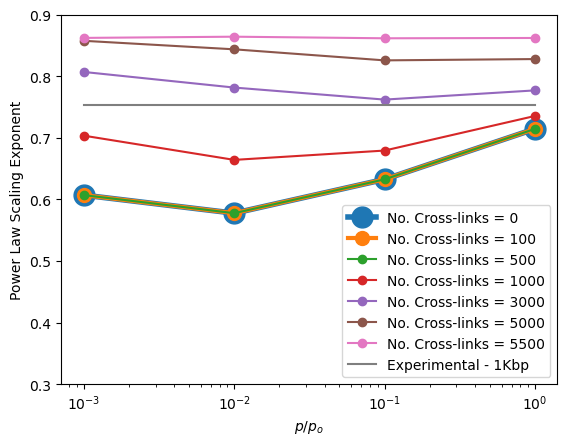

In [ ]:
#Power law scaling exponents of ligation probabilities as a function of ligation rate for different crosslinkinf efficiencies

xls_legend = ['No. Cross-links = '+str(0),'No. Cross-links = '+str(100),'No. Cross-links = '+str(500), 'No. Cross-links = '+str(1000), 'No. Cross-links = '+str(3000), 'No. Cross-links = '+str(5000), 'No. Cross-links = '+str(5500), 'Experimental - 1Kbp', ]

plt.plot(lig_probs, params_0000, marker = 'o', markersize=15, linewidth=4)
plt.plot(lig_probs, params_0100, marker = 'o', markersize=10, linewidth=3)
plt.plot(lig_probs, params_0500, marker = 'o')
plt.plot(lig_probs, params_1000, marker = 'o')
plt.plot(lig_probs, params_3000, marker = 'o')
plt.plot(lig_probs, params_5000, marker = 'o')
plt.plot(lig_probs, params_5500, marker = 'o')


x = [1e-3, 1]
y = [abs(params_exp[1]),abs(params_exp[1])]

plt.plot(x, y)

plt.ylabel('Power Law Scaling Exponent')

plt.xlabel(r'$p/p_{o} $')

#plt.yscale("log")
plt.xscale("log")

plt.legend(xls_legend, loc='lower right')

plt.ylim([0.30,0.9])

plt.show()



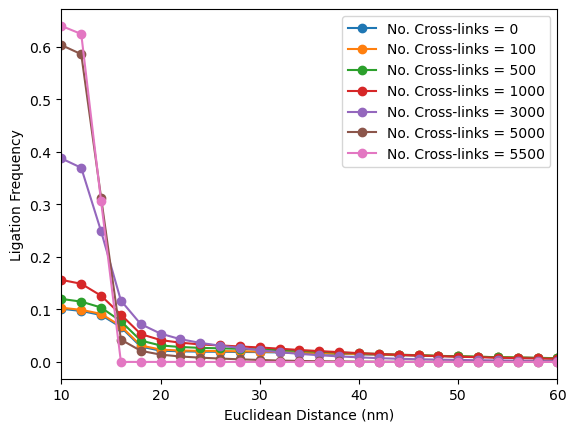

In [ ]:
#Ligation probability as a function of Euclidean distance for different crosslinking efficiencies

plt.plot(10*ld_xl_0[0:49],pl1_xl_0[0], '-o')
plt.plot(10*ld_xl_100[0:49],pl1_xl_100[0], '-o')
plt.plot(10*ld_xl_500[0:49],pl1_xl_500[0], '-o')
plt.plot(10*ld_xl_1000[0:49],pl1_xl_1000[0], '-o')
plt.plot(10*ld_xl_3000[0:49],pl1_xl_3000[0], '-o')
plt.plot(10*ld_xl_5000[0:49],pl1_xl_5000[0], '-o')
plt.plot(10*ld_xl_5000[0:49],pl1_xl_5500[0], '-o')

#plt.plot(10*ld[0:49],pl1[5], '-o')
plt.legend(xlbeads_legend)
plt.xlim([10,60])
#plt.ylim([0,0.02])
#plt.yscale("log")
plt.xlabel('Euclidean Distance (nm)')
plt.ylabel('Ligation Frequency')
plt.show()

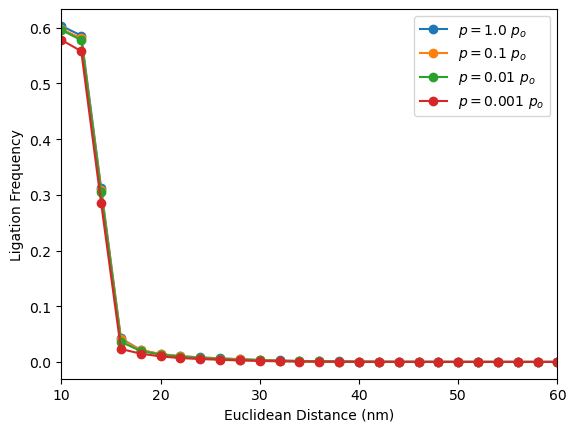

In [ ]:
#Ligation probability as a function of Euclidean distance for different ligation rates and maximal crosslinking.
#This illustrates that the structure is frozen and conformational information preserved

plt.plot(10*ld_xl_5000[0:49],pl1_xl_5000[0], '-o')
plt.plot(10*ld_xl_5000[0:49],pl1_xl_5000[1], '-o')
plt.plot(10*ld_xl_5000[0:49],pl1_xl_5000[2], '-o')
plt.plot(10*ld_xl_5000[0:49],pl1_xl_5000[3], '-o')

#plt.plot(10*ld[0:49],pl1[5], '-o')
plt.legend(p_legend)
plt.xlim([10,60])
#plt.ylim([0,0.02])
#plt.yscale("log")
plt.xlabel('Euclidean Distance (nm)')
plt.ylabel('Ligation Frequency')
plt.show()